<a href="https://colab.research.google.com/github/helloohowareyu/Praktikum-Kecerdasan-Artifisial-Lanjut/blob/main/Praktikum_8_K_Means_dan_DBSCAN_Soal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 11. Evaluasi Clustering


### 1) Persiapan

Import library

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
data = load_iris()
X = data.data
Y = data.target

Clustering

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

Evaluasi

In [4]:
sil_score = silhouette_score(X, labels)
ch_score = calinski_harabasz_score(X, labels)
db_index = davies_bouldin_score(X, labels)
rand_index = adjusted_rand_score(Y, labels)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)
print("Calinski-Harabasz Index:", ch_score)
print("Adjusted Rand Index:", rand_index)

Silhouette Score: 0.551191604619592
Davies-Bouldin Index: 0.6660385791628493
Calinski-Harabasz Index: 561.5937320156642
Adjusted Rand Index: 0.7163421126838476


In [6]:
def purity_score(y_true, y_pred):
    contingency_matrix = np.zeros((np.max(y_pred)+1, np.max(y_true)+1))
    for i in range(len(y_true)):
        contingency_matrix[y_true[i], y_pred[i]] += 1
    return np.sum(np.max(contingency_matrix, axis=1)) / np.sum(contingency_matrix)

purity = purity_score(Y, labels)
print("Purity Score:", purity)

Purity Score: 0.8866666666666667


Visualisasi Cluster

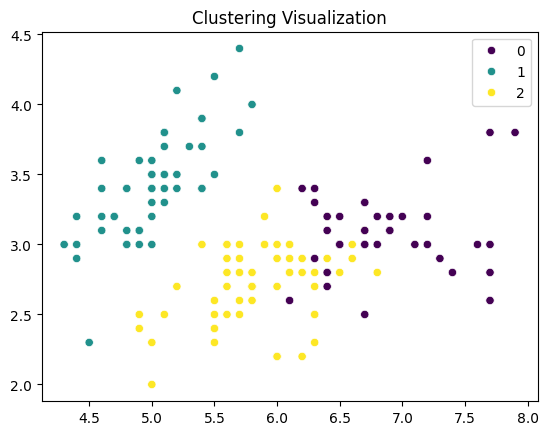

In [7]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis')
plt.title('Clustering Visualization')
plt.show()

## 2) Tugas

1 ) Uji evaluasi clustering untuk jumlah cluster 2 hingga 6. Catat dan bandingkan hasilnya


In [8]:
results = []

k_values = range(2, 7)

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X)

  sil_score = silhouette_score(X, labels)
  ch_score = calinski_harabasz_score(X, labels)
  db_index = davies_bouldin_score(X, labels)

  results.append({
        'Jumlah Cluster (k)': k,
        'Silhouette Score': round(sil_score , 4),
        'Davies-Bouldin Index': round(db_index, 4),
        'Calinski-Harabasz Index': round(ch_score, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Jumlah Cluster (k),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.6810,0.4043,513.9245
1,3,0.5528,0.6620,561.6278
2,4,0.4981,0.7803,530.7658
3,5,0.4912,0.8160,495.3699
4,6,0.3648,0.9142,473.8506


**Penjelasan Kode Program**

Secara garis besar, program melakukan pengujian performa algoritma K-Means dengan memvariasikan jumlah kelompok (cluster). Perubahan Utama pada kode program ada pada penggunaan fungsi range(2, 7) untuk melakukan iterasi. Angka 7 sebagai batas atas memastikan program menguji jumlah cluster tepat dari 2, 3, 4, 5, hingga 6. Model K-Means dibuat ulang di setiap perulangan dengan parameter `n_clusters` yang berbeda. Algoritma mengelompokkan data berdasarkan fitur yang tersedia. Di setiap nilai $k$, program menghitung tiga metrik, yaitu Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index.Hasil skor disimpan dalam sebuah tabel (DataFrame) dan dipetakan ke dalam tabel untuk mempermudah perbandingan tren kenaikan atau penurunan skor.



**Analisis**

1. Silhouette Score

   Nilai tertinggi dicapai pada k=2 (0.681). Hal ini menunjukkan bahwa secara matematis, pembagian menjadi 2 kelompok memberikan pemisahan antar cluster yang paling bersih. Namun, pada k=3, skornya masih cukup tinggi (0.5528).

2. Davies-Bouldin Index

   Nilai terendah (terbaik) berada pada k=2 (0.4051). Semakin kecil angka ini, semakin rendah tumpang tindih (overlap) antar cluster. Angka ini terus naik (memburuk) seiring bertambahnya jumlah cluster.

3. Calinski-Harabasz Index

   Berbeda dengan dua metrik sebelumnya, indeks ini justru mencapai puncaknya pada k=3 (561.6278). Hal ini menandakan bahwa struktur 3 cluster memberikan rasio dispersi antar kelompok yang paling optimal.

2 ) Coba dataset Wine dari sklearn.datasets. Lakukan evaluasi clustering dan bandingkan hasilnya

In [9]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = wine.data
Y = wine.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

result_wine = []
k_values = range(2, 7)

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)

  sil_score = silhouette_score(X_scaled, labels)
  ch_score = calinski_harabasz_score(X_scaled, labels)
  db_index = davies_bouldin_score(X_scaled, labels)

  result_wine.append({
        'Jumlah Cluster (k)': k,
        'Silhouette Score': round(sil_score , 4),
        'Davies-Bouldin Index': round(db_index, 4),
        'Calinski-Harabasz Index': round(ch_score, 4)
    })

result_wine_df = pd.DataFrame(result_wine)
display(result_wine_df)

,Jumlah Cluster (k),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.2593,1.5260,69.5233
1,3,0.2849,1.3892,70.9400
2,4,0.2602,1.7969,56.1814
3,5,0.2016,1.8083,46.9522
4,6,0.2372,1.5544,41.7008


**Analisis**

1. Silhouette Score

   Skor tertinggi dicapai pada k=3 dengan nilai 0.2849. Angka ini merupakan yang terbaik dibandingkan k=2 (0.2593) maupun jumlah cluster yang lebih banyak seperti k=4 (0.2573). Hal ini membuktikan bahwa pada pembagian 3 cluster, titik-titik data berada di kelompok yang tepat dengan jarak yang cukup baik terhadap cluster tetangganya.

2. Davies-Bouldin Index

   Terlihat sangat jelas dari tabel bahwa nilai terendah (terbaik) didapatkan pada k=3 dengan skor 1.3892. Semakin banyak cluster ditambahkan (seperti k=6), kinerjanya semakin memburuk hingga menyentuh angka 1.8596.

3. Calinski-Harabasz Index

   Skor puncaknya kembali diraih secara solid oleh k=3 dengan nilai 70.9400, mengungguli k=2 (65.0118) dan terus mengalami penurunan drastis hingga k=6 (49.1917).

Hasil ini sangat relevan dan membuktikan keandalan algoritma K-Means karena pembagian 3 cluster ini berhasil menebak ground truth (fakta asli) dari dataset Wine scikit-learn yang memang terdiri dari 3 kelas (tiga jenis kultivar anggur yang berbeda).

**Kesimpulan**

Berbeda dengan dataset Iris pada tugas sebelumnya yang memberikan sedikit ambiguitas antara metrik (ada metrik yang condong ke $k=2$, ada yang ke $k=3$), hasil evaluasi pada dataset Wine menunjukkan kesamaan yang sangat solid di antara ketiga metrik.



3 ) Jelaskan kapan Silhouette Score lebih baik daripada Davies-Bouldin Index

1. Ketika Kita Butuh Interpretasi Skor yang Pasti dan Jelas

    Silhouette Score memiliki batas rentang nilai yang sangat jelas, yaitu dari -1 hingga 1. Angka mendekati 1 berarti clustering sangat bagus, angka 0 berarti data tumpang tindih, dan negatif berarti data salah masuk kelompok. Rentang yang pasti ini membuatnya sangat mudah dipahami.

    Sebaliknya, Davies-Bouldin Index (DBI) tidak memiliki batas atas (nilainya dari 0 hingga tak terhingga). Hal ini membuat DBI agak sulit diinterpretasikan secara absolut (hanya bisa membandingkannya dengan model lain untuk mencari yang nilainya paling kecil).

2. Ketika Dataset Memiliki Kepadatan dan Ukuran Cluster yang Berbeda-beda

    Silhouette Score menghitung jarak dari setiap individu data ke seluruh data lainnya, baik di dalam clusternya sendiri maupun di cluster tetangga terdekatnya. Ini membuatnya lebih stabil jika ada cluster yang satu sangat padat, sedangkan cluster yang lain menyebar.

    Di sisi lain, DBI bekerja dengan membandingkan jarak ke titik pusat (centroid) dari masing-masing cluster. DBI sangat berasumsi bahwa cluster berbentuk bulat sempurna (spherical). Jika bentuk atau ukuran antar cluster sangat timpang, DBI seringkali memberikan skor yang menyesatkan.

3. Untuk Melihat Detail Performa Data Individual

    Karena Silhouette Score dihitung untuk setiap titik data secara individu (sebelum dirata-rata menjadi skor total), kita bisa memvisualisasikan data mana saja yang menjadi "outlier" atau berada di perbatasan (garis abu-abu) antar cluster. DBI hanya memberikan satu skor perhitungan skala makro dari centroid tanpa bisa dipecah per individu data.

### Kesimpulan

1. Pencapaian Tujuan Percobaan

   Tujuan percobaan telah tercapai dengan sangat baik. Praktikum ini berhasil mengimplementasikan dan membandingkan tiga metrik evaluasi internal clustering (tanpa label), yaitu Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index menggunakan algoritma K-Means pada rentang nilai $k=2$ hingga $k=6$.
   
2. Hubungan Antara Hasil Percobaan dan Dasar Teori

   Hasil eksperimen sangat sesuai dengan dasar teori evaluasi clustering yang menyatakan bahwa hasil clustering yang baik ditandai dengan tingginya pemisahan antar cluster dan padatnya data di dalam cluster. Hal ini terbukti pada pengujian dataset Wine, di mana nilai $k=3$ secara konsisten mencetak Silhouette Score tertinggi, Davies-Bouldin Index terendah (karena metrik ini rasio yang mencari nilai minimum), dan Calinski-Harabasz Index tertinggi. Hasil $k=3$ tersebut sangat akurat dan sejalan dengan ground truth (fakta label asli) dataset Wine yang memang memiliki 3 kelas kultivar, membuktikan bahwa metrik evaluasi tersebut dapat diandalkan untuk mencari jumlah kelompok optimal.
   
3. Faktor-Faktor yang Memengaruhi Hasil dan Kemungkinan Kesalahan

   Preprocessing Data (Standardisasi):
   
   Ini adalah faktor paling krusial karena perbedaan skala fitur yang sangat jauh pada dataset Wine. Tanpa standardisasi, perhitungan jarak akan didominasi oleh nilai fitur yang besar, sehingga hasil clustering dan skor evaluasinya akan hancur/tidak valid.
  